# Day 10: Mall Customer Dataset Analysis  Pure Matplotlib)
EDA and customer behavior analysis using the Mall Customers dataset (`Mall_Customers.csv`). All plots use Matplotlib and Pandas.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set visual style
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 12


### Step 1: Load Dataset


In [21]:
df = pd.read_csv("../../DataSet/Mall_Customers.csv")
print("Mall Customer dataset loaded!")
df

Mall Customer dataset loaded!


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


### Step 2: Check Shape


In [3]:
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.shape


Shape: 200 rows, 5 columns


(200, 5)

### Step 3: View Dataset Information


In [4]:
df.head()


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
df.tail()


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


### Step 4: Check Data Types


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


### Step 5: Identify Missing Values


In [7]:
df.isnull().sum()


CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

### Step 6: Handle Missing Values


In [8]:
print("No missing values to handle.")


No missing values to handle.


### Step 7: Check Duplicate Records


In [9]:
duplicates = df.duplicated().sum()
print("Duplicates count:", duplicates)
if duplicates > 0:
    display(df[df.duplicated(keep=False)])


Duplicates count: 0


### Step 8: Remove Duplicates


In [10]:
df.drop_duplicates(inplace=True)


### Step 9: Generate Statistical Summary


In [11]:
df.describe()


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


### Step 10: Outlier Detection


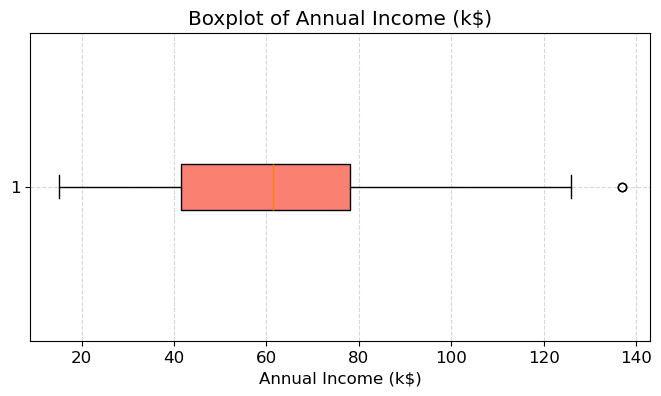

Outlier limits: Lower = -13.25, Upper = 132.75
Outliers count: 2


In [12]:
# Check Boxplot for Annual Income using Matplotlib
plt.figure(figsize=(8, 4))
plt.boxplot(df["Annual Income (k$)"], vert=False, patch_artist=True, boxprops=dict(facecolor="salmon"))
plt.title("Boxplot of Annual Income (k$)")
plt.xlabel("Annual Income (k$)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# Calculating IQR
Q1 = df["Annual Income (k$)"].quantile(0.25)
Q3 = df["Annual Income (k$)"].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + 1.5 * IQR
lower_limit = Q1 - 1.5 * IQR
print(f"Outlier limits: Lower = {lower_limit}, Upper = {upper_limit}")
print("Outliers count:", len(df[df["Annual Income (k$)"] > upper_limit]))


### Step 11: Perform Univariate Analysis


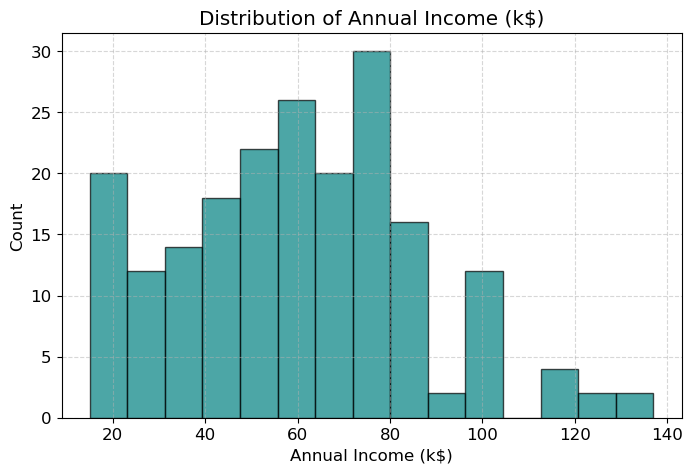

In [13]:
# Fix the user's syntax error: plt.bar(df["Annual Income (k$)"].value_counts(), height=True)
# We replace it with a clean Matplotlib histogram distribution plot

plt.figure(figsize=(8, 5))
plt.hist(df["Annual Income (k$)"], bins=15, color="teal", edgecolor="black", alpha=0.7)
plt.title("Distribution of Annual Income (k$)")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Count")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


### Step 12: Perform Bivariate Analysis


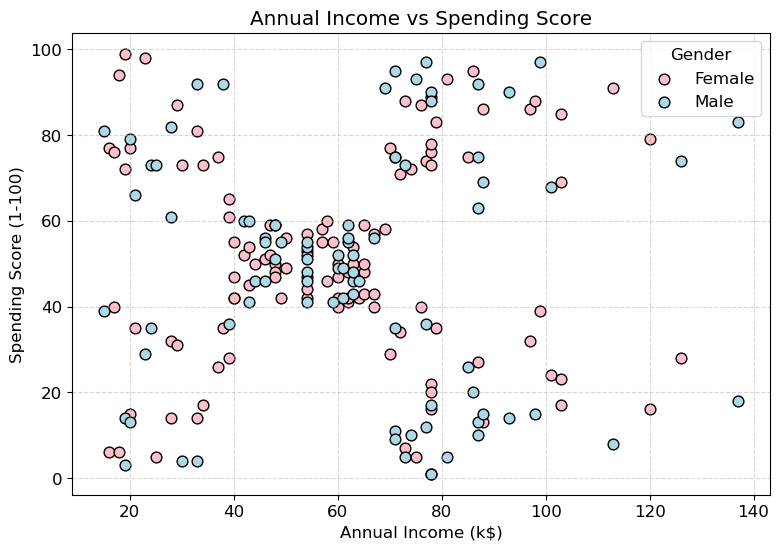

In [14]:
# Plot Annual Income vs Spending Score
plt.figure(figsize=(9, 6))
# Separate groups manually to plot with different colors without Seaborn
females = df[df["Genre"] == "Female"]
males = df[df["Genre"] == "Male"]

plt.scatter(females["Annual Income (k$)"], females["Spending Score (1-100)"], color="pink", label="Female", edgecolor="black", s=60)
plt.scatter(males["Annual Income (k$)"], males["Spending Score (1-100)"], color="lightblue", label="Male", edgecolor="black", s=60)

plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend(title="Gender")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


In [15]:
# Target Group Identification (Middle Income, High Spending Customers)
target_group = df[(df['Annual Income (k$)'] >= 40) & 
                  (df['Annual Income (k$)'] <= 70) & 
                  (df['Spending Score (1-100)'] > 60)]

print(f"Target group shape: {target_group.shape}")
target_group.head()


Target group shape: (2, 5)


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
123,124,Male,39,69,91
125,126,Female,31,70,77


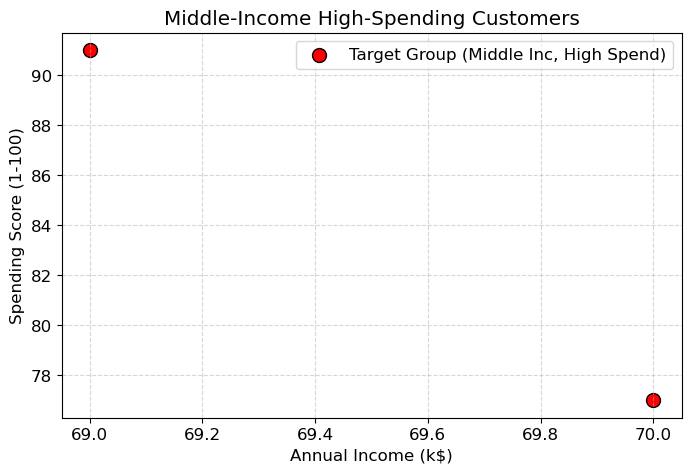

In [16]:
# Visualize Target Group
plt.figure(figsize=(8, 5))
plt.scatter(target_group['Annual Income (k$)'], target_group['Spending Score (1-100)'], 
            color='red', label='Target Group (Middle Inc, High Spend)', edgecolor='black', s=100)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Middle-Income High-Spending Customers")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


### Step 13: Correlation Analysis


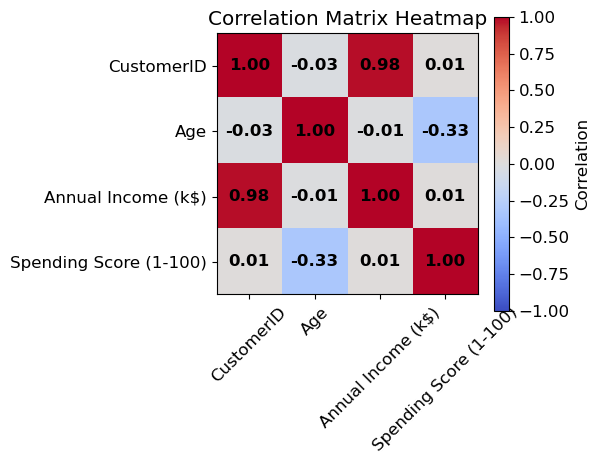

In [17]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(6, 5))
plt.imshow(corr, cmap="coolwarm", interpolation="none", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", color="black", fontweight="bold")

plt.title("Correlation Matrix Heatmap")
plt.tight_layout()
plt.show()


### Step 14: Feature Engineering


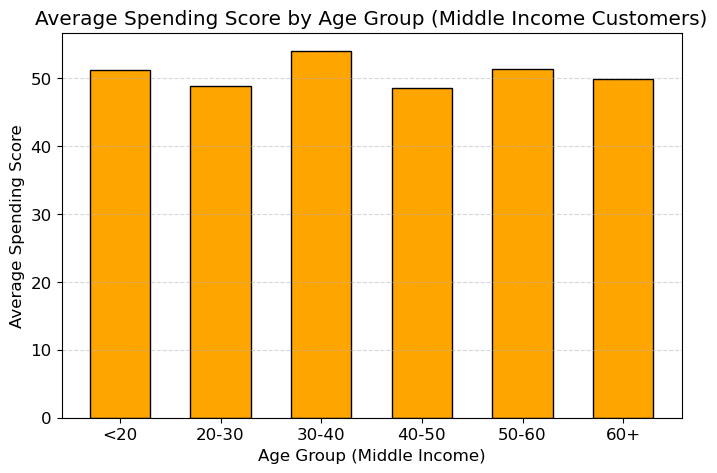

In [18]:
# Let's bin Ages to understand spending habits of middle-income customers
middle_income = df[(df['Annual Income (k$)'] >= 40) & (df['Annual Income (k$)'] <= 70)].copy()

middle_income['AgeGroup'] = pd.cut(middle_income['Age'], 
                                   bins=[0,20,30,40,50,60,70], 
                                   labels=['<20','20-30','30-40','40-50','50-60','60+'])

age_spending = middle_income.groupby('AgeGroup', observed=False)['Spending Score (1-100)'].mean()

plt.figure(figsize=(8, 5))
plt.bar(age_spending.index.astype(str), age_spending.values, color="orange", edgecolor="black", width=0.6)
plt.xlabel("Age Group (Middle Income)")
plt.ylabel("Average Spending Score")
plt.title("Average Spending Score by Age Group (Middle Income Customers)")
plt.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.show()


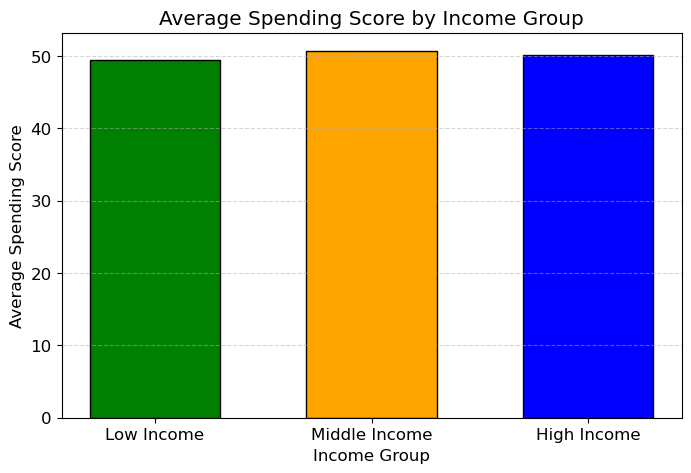

In [19]:
# Let's bin Income Groups to analyze overall spending differences
df_eng = df.copy()
df_eng['IncomeGroup'] = pd.cut(df_eng['Annual Income (k$)'], 
                            bins=[0,40,70,150], 
                            labels=['Low Income','Middle Income','High Income'])

income_spending = df_eng.groupby('IncomeGroup', observed=False)['Spending Score (1-100)'].mean()

plt.figure(figsize=(8, 5))
plt.bar(income_spending.index.astype(str), income_spending.values, color=["green", "orange", "blue"], edgecolor="black", width=0.6)
plt.xlabel("Income Group")
plt.ylabel("Average Spending Score")
plt.title("Average Spending Score by Income Group")
plt.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.show()


### Step 15: Draw Conclusions and Insights
1. **Five Customer Segments**: The scatter plot of Annual Income vs Spending Score shows 5 distinct clusters:
   * Low Income, Low Spend
   * Low Income, High Spend
   * Mid Income, Mid Spend (average spending score ~50)
   * High Income, Low Spend
   * High Income, High Spend
2. **Age Group Dynamics**: Among middle-income customers, the 20-30 and 30-40 age groups show the highest average spending scores, suggesting marketing campaigns should target younger individuals.
3. **Outliers**: There is one minor outlier on the upper end of annual income (above 137k$), which falls outside the standard 1.5 * IQR boundary.


In [20]:
df

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
